In [ ]:
%pip install prefect datasets matplotlib

In [1]:
from prefect import flow

@flow(log_prints=True)
def hello(name: str = "Akilesh") -> None:
    print(f"Hello, {name}!")

if __name__ == "__main__":
    hello()           # Logs: "Hello, Akilesh!"
    hello("London")   # Logs: "Hello, London!"


11:20:09.659 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8489
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

11:20:12.317 | INFO    | Flow run 'lumpy-ringtail' - Beginning flow run 'lumpy-ringtail' for flow 'hello'

11:20:12.320 | INFO    | Flow run 'lumpy-ringtail' - Hello, Akilesh!

11:20:12.329 | INFO    | Flow run 'lumpy-ringtail' - Finished in state Completed()

11:20:12.400 | INFO    | Flow run 'kind-herring' - Beginning flow run 'kind-herring' for flow 'hello'

11:20:12.401 | INFO    | Flow run 'kind-herring' - Hello, London!

11:20:12.413 | INFO    | Flow run 'kind-herring' - Finished in state Completed()

In [2]:
from prefect import flow, task
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
@task
def load_hf_dataset(repo_name: str):
    # Loads the train split and returns a pandas DataFrame
    dataset = load_dataset(repo_name)
    df = dataset["train"].to_pandas()
    return df

In [4]:
@task
def clean_data(df: pd.DataFrame):
    # Cleans duplicates/missing values
    df_clean = df.drop_duplicates().dropna().reset_index(drop=True)
    return df_clean

In [5]:
@task
def reviews_by_month(df: pd.DataFrame):
    # Defensive check for 'date' and 'star' columns
    if 'date' not in df.columns or 'star' not in df.columns:
        print(f"Available columns: {list(df.columns)}")
        raise ValueError("Required columns not found! Please check the DataFrame.")
    # Parse date strings to datetime
    df['date'] = pd.to_datetime(df['date'])
    # Group by Year/Month and aggregate
    df['year_month'] = df['date'].dt.to_period('M')
    summary = df.groupby('year_month')['star'].agg(['count', 'mean']).rename(columns={'count': 'num_reviews', 'mean': 'avg_star'})
    return summary

In [6]:
@task
def plot_summary(summary):
    # Plots num_reviews and avg_star over time
    fig, ax1 = plt.subplots(figsize=(8,4))
    summary['num_reviews'].plot(kind='bar', color='skyblue', ax=ax1)
    ax1.set_ylabel('Number of Reviews', color='blue')
    ax1.set_xlabel('Year-Month')
    ax2 = ax1.twinx()
    summary['avg_star'].plot(color='orange', marker='o', ax=ax2)
    ax2.set_ylabel('Average Star Rating', color='orange')
    plt.title("App Reviews: Count and Average Rating by Month")
    plt.tight_layout()
    plt.show()
    return summary

In [7]:
@flow(log_prints=True)
def hf_review_analysis_pipeline(repo_name: str = "stevhliu/demo"):
    df = load_hf_dataset(repo_name)
    df_clean = clean_data(df)
    summary = reviews_by_month(df_clean)
    print(summary)
    plot_summary(summary)

11:20:19.448 | INFO    | Flow run 'inescapable-rottweiler' - Beginning flow run 'inescapable-rottweiler' for flow 'hf-review-analysis-pipeline'

11:20:24.039 | INFO    | Task run 'load_hf_dataset-0ae' - Finished in state Completed()

11:20:24.084 | INFO    | Task run 'clean_data-14c' - Finished in state Completed()

11:20:24.140 | INFO    | Task run 'reviews_by_month-705' - Finished in state Completed()

11:20:24.146 | INFO    | Flow run 'inescapable-rottweiler' -             num_reviews  avg_star
year_month                       
2016-07               2       4.0
2016-08               2       4.5
2016-10               1       4.0

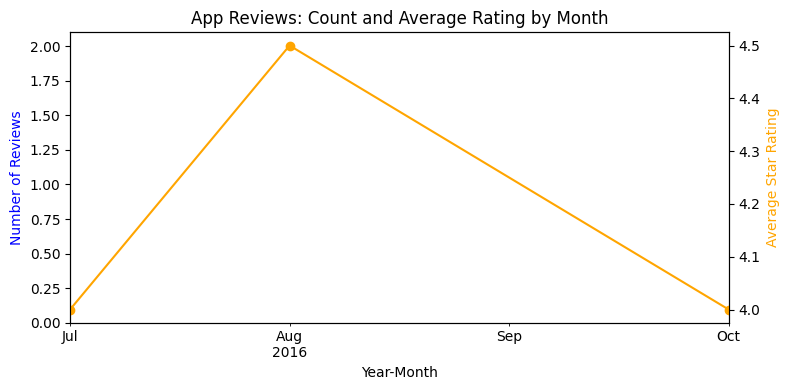

11:20:24.480 | INFO    | Task run 'plot_summary-533' - Finished in state Completed()

11:20:24.497 | INFO    | Flow run 'inescapable-rottweiler' - Finished in state Completed()

In [8]:
hf_review_analysis_pipeline("stevhliu/demo")